In [4]:
import os
import pandas as pd
from dotenv import load_dotenv
from supabase import create_client

# 1. Load credentials from .env
load_dotenv()

url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_KEY")

# 2. Connect to Supabase
supabase = create_client(url, key)

# 3. Fetch first 5 rows from telco_churn
response = supabase.table("telco_churn").select("*").execute()

# 4. Display as Pandas DataFrame
df = pd.DataFrame(response.data)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3842-IYKUE,Female,0,No,No,35,Yes,Yes,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Credit card (automatic),85.30,2917.5,Yes
996,6641-XRPSU,Female,0,No,No,34,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),70.00,2416.1,Yes
997,1374-DMZUI,Female,1,No,No,4,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.30,424.45,Yes
998,2545-LXYVJ,Male,0,Yes,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),20.70,1492.1,No


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1000 non-null   str    
 1   gender            1000 non-null   str    
 2   SeniorCitizen     1000 non-null   int64  
 3   Partner           1000 non-null   str    
 4   Dependents        1000 non-null   str    
 5   tenure            1000 non-null   int64  
 6   PhoneService      1000 non-null   str    
 7   MultipleLines     1000 non-null   str    
 8   InternetService   1000 non-null   str    
 9   OnlineSecurity    1000 non-null   str    
 10  OnlineBackup      1000 non-null   str    
 11  DeviceProtection  1000 non-null   str    
 12  TechSupport       1000 non-null   str    
 13  StreamingTV       1000 non-null   str    
 14  StreamingMovies   1000 non-null   str    
 15  Contract          1000 non-null   str    
 16  PaperlessBilling  1000 non-null   str    
 17  Payment

# Theory: Corrolation check between Churn and PaymentMethod

In [6]:
print(df['PaymentMethod'].unique())

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str


We have 4 different payment methods

In [7]:
print(df['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             310
Bank transfer (automatic)    243
Credit card (automatic)      230
Mailed check                 217
Name: count, dtype: int64


We can see that it's pretty even between the payment methods

Let's see how the look when we compare them with churning customers

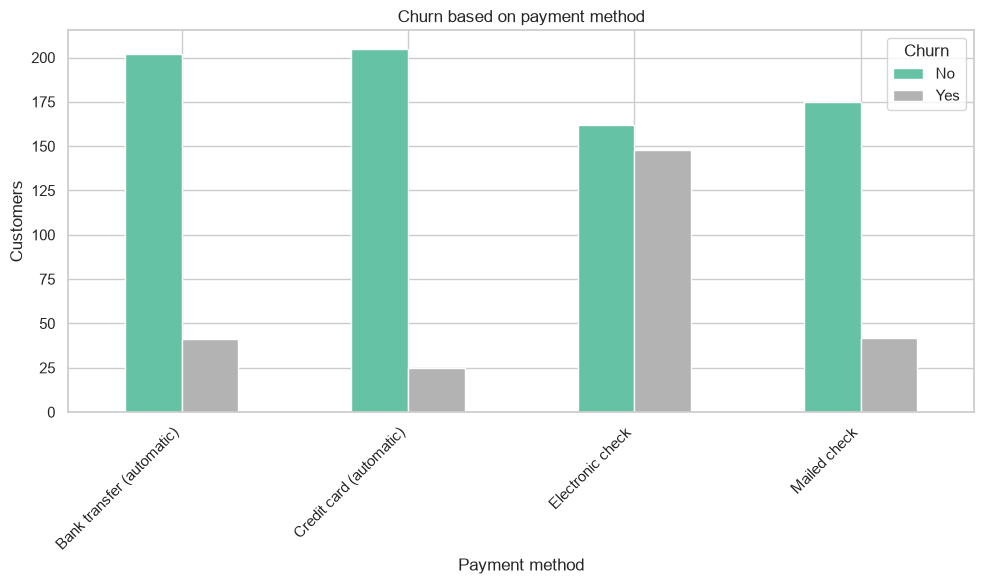

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pm_c = pd.crosstab(df['PaymentMethod'], df['Churn'])

pm_c.plot(kind='bar', figsize=(10,6), colormap='Set2')

plt.title('Churn based on payment method')
plt.xlabel('Payment method')
plt.ylabel('Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Churn')
plt.tight_layout()

plt.show()

As we can see we have a huge Churn on the people using electronic checks

This is something we need to look deeper into. Who uses it and does we have any other things related to the "EC" customers